In [2]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import XGBoost dan Sklearn Metrics
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Setup tema plot
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

print("Library untuk pemodelan XGBoost berhasil dimuat!")

Library untuk pemodelan XGBoost berhasil dimuat!


In [5]:
# ==========================================
# 2. LOAD PRE-PROCESSED DATA
# ==========================================
# Ganti nama file jika letaknya di folder berbeda
train_df = pd.read_csv(r'E:\Python - Project\phone-addiction-detection\Data\train_preprocessed_smote.csv')
test_df = pd.read_csv(r'E:\Python - Project\phone-addiction-detection\Data\test_preprocessed.csv')

# Memisahkan Fitur (X) dan Target (y)
X_train = train_df.drop(columns=['addicted_label'])
y_train = train_df['addicted_label']

X_test = test_df.drop(columns=['addicted_label'])
y_test = test_df['addicted_label']

print(f"Dimensi Data Latih (X_train): {X_train.shape}")
print(f"Dimensi Data Uji (X_test): {X_test.shape}")
print("Data siap dilatih!")

Dimensi Data Latih (X_train): (8492, 14)
Dimensi Data Uji (X_test): (1500, 14)
Data siap dilatih!


In [6]:
# ==========================================
# 3. TRAINING XGBOOST MODEL
# ==========================================
# Inisialisasi Model XGBoost
xgb_model = xgb.XGBClassifier(
    learning_rate=0.1,        # Kecepatan belajar model
    n_estimators=100,         # Jumlah pohon (trees)
    max_depth=5,              # Kedalaman maksimal setiap pohon
    subsample=0.8,            # Mengambil 80% sampel untuk setiap pohon (mencegah overfitting)
    colsample_bytree=0.8,     # Mengambil 80% fitur untuk setiap pohon
    random_state=42,          # Agar hasil bisa direplikasi
    eval_metric='logloss'     # Metrik evaluasi internal XGBoost
)

# Melatih Model
print("Sedang melatih model XGBoost... Mohon tunggu.")
xgb_model.fit(X_train, y_train)
print("Pelatihan model XGBoost selesai!")

Sedang melatih model XGBoost... Mohon tunggu.
Pelatihan model XGBoost selesai!


=== CLASSIFICATION REPORT (XGBOOST) ===
                     precision    recall  f1-score   support

Tidak Kecanduan (0)       0.85      0.97      0.91       438
      Kecanduan (1)       0.99      0.93      0.96      1062

           accuracy                           0.94      1500
          macro avg       0.92      0.95      0.93      1500
       weighted avg       0.95      0.94      0.94      1500



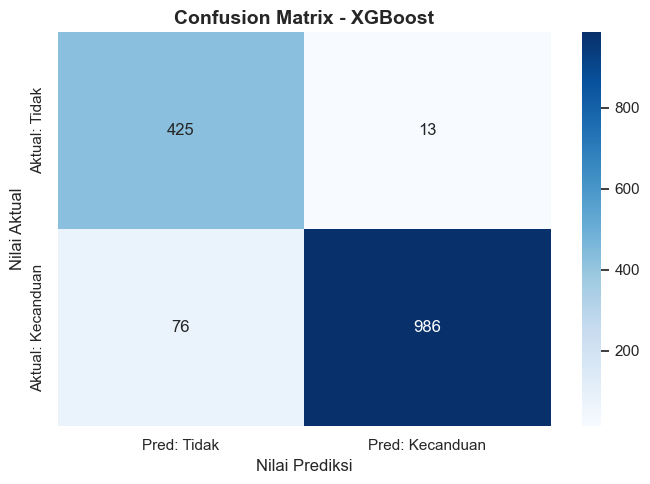


Akurasi Keseluruhan XGBoost: 94.07%


In [7]:
# ==========================================
# 4. EVALUASI KINERJA MODEL
# ==========================================
# Memprediksi data uji
y_pred_xgb = xgb_model.predict(X_test)

# 1. Classification Report
print("=== CLASSIFICATION REPORT (XGBOOST) ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Tidak Kecanduan (0)', 'Kecanduan (1)']))

# 2. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred: Tidak', 'Pred: Kecanduan'], 
            yticklabels=['Aktual: Tidak', 'Aktual: Kecanduan'])
plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Prediksi')
plt.ylabel('Nilai Aktual')
plt.tight_layout()
plt.show()

# Insight untuk jurnal
akurasi = accuracy_score(y_test, y_pred_xgb)
print(f"\nAkurasi Keseluruhan XGBoost: {akurasi * 100:.2f}%")

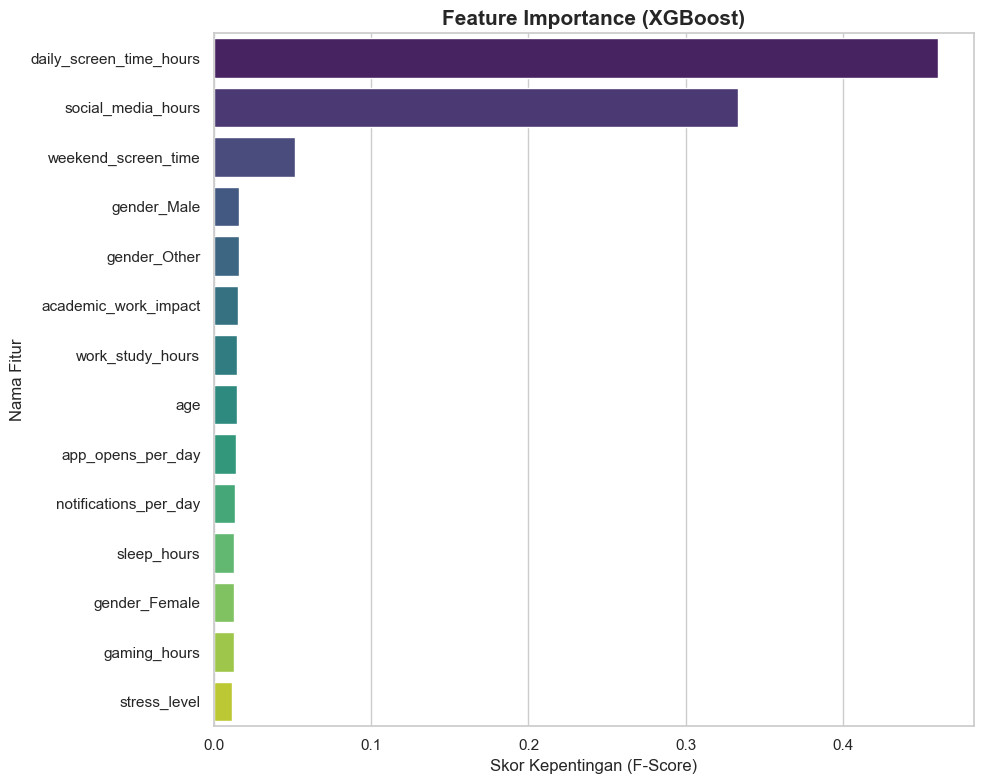

=== 5 FITUR PALING BERPENGARUH ===
                  Fitur  Tingkat_Kepentingan
daily_screen_time_hours             0.460098
     social_media_hours             0.333423
    weekend_screen_time             0.051674
            gender_Male             0.015919
           gender_Other             0.015816


In [8]:
# ==========================================
# 5. FEATURE IMPORTANCE VISUALIZATION
# ==========================================
# Mengambil nilai kepentingan fitur dari model
importances = xgb_model.feature_importances_
feature_names = X_train.columns

# Membuat DataFrame untuk di-sorting
feature_imp_df = pd.DataFrame({
    'Fitur': feature_names,
    'Tingkat_Kepentingan': importances
}).sort_values(by='Tingkat_Kepentingan', ascending=False)

# Visualisasi Barplot
plt.figure(figsize=(10, 8))
sns.barplot(x='Tingkat_Kepentingan', y='Fitur', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance (XGBoost)', fontsize=15, fontweight='bold')
plt.xlabel('Skor Kepentingan (F-Score)')
plt.ylabel('Nama Fitur')
plt.tight_layout()
plt.show()

print("=== 5 FITUR PALING BERPENGARUH ===")
print(feature_imp_df.head(5).to_string(index=False))

=== PENGECEKAN OVERFITTING ===
Akurasi Data Latih (Training) : 97.81%
Akurasi Data Uji (Testing)    : 94.07%
Selisih Akurasi               : 3.74%

✅ Indikasi: Model FIT DENGAN BAIK (Good Fit). Tidak ada gejala overfitting yang signifikan.

Menghasilkan Kurva Pembelajaran (Learning Curve)...


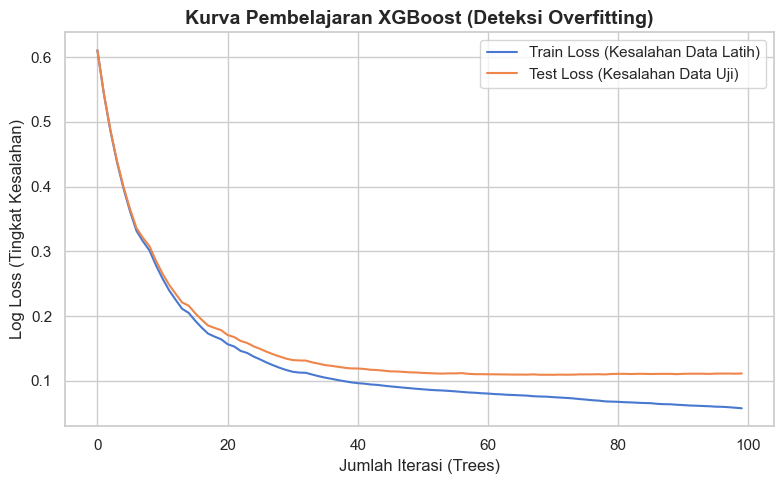

In [9]:
# ==========================================
# 6. DETEKSI OVERFITTING & LEARNING CURVE
# ==========================================

# 1. Komparasi Akurasi Latih vs Akurasi Uji
y_pred_train = xgb_model.predict(X_train)
akurasi_train = accuracy_score(y_train, y_pred_train)
akurasi_test = accuracy_score(y_test, y_pred_xgb) # y_pred_xgb dari tahap sebelumnya

print("=== PENGECEKAN OVERFITTING ===")
print(f"Akurasi Data Latih (Training) : {akurasi_train * 100:.2f}%")
print(f"Akurasi Data Uji (Testing)    : {akurasi_test * 100:.2f}%")
selisih = abs(akurasi_train - akurasi_test) * 100
print(f"Selisih Akurasi               : {selisih:.2f}%\n")

if selisih > 5:
    print("⚠️ Indikasi: Model mengalami OVERFITTING (Selisih > 5%). Coba turunkan max_depth atau naikkan regularisasi (gamma/alpha).")
else:
    print("✅ Indikasi: Model FIT DENGAN BAIK (Good Fit). Tidak ada gejala overfitting yang signifikan.")

# 2. Visualisasi Kurva Pembelajaran (Log Loss Curve)
# Untuk membuat kurva ini, kita perlu me-retrain model sebentar menggunakan eval_set
print("\nMenghasilkan Kurva Pembelajaran (Learning Curve)...")
eval_set = [(X_train, y_train), (X_test, y_test)]
xgb_model_eval = xgb.XGBClassifier(
    learning_rate=0.1, n_estimators=100, max_depth=5, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, 
    eval_metric='logloss'
)

# Fit model dengan mencatat performa di setiap iterasi (tree)
xgb_model_eval.fit(X_train, y_train, eval_set=eval_set, verbose=False)
results = xgb_model_eval.evals_result()

# Plotting
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(8, 5))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train Loss (Kesalahan Data Latih)')
plt.plot(x_axis, results['validation_1']['logloss'], label='Test Loss (Kesalahan Data Uji)')
plt.legend()
plt.ylabel('Log Loss (Tingkat Kesalahan)')
plt.xlabel('Jumlah Iterasi (Trees)')
plt.title('Kurva Pembelajaran XGBoost (Deteksi Overfitting)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# DETEKSI TARGET LEAKAGE (KEBOCORAN DATA)
# ==========================================
import pandas as pd
import numpy as np

# Load raw dataset (untuk mendemonstrasikan pencarian kebocoran)
df_raw = pd.read_csv(r'E:\Python - Project\phone-addiction-detection\Data\Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

print("=== ANALISIS TARGET LEAKAGE ===")

# 1. Pengecekan Melalui Korelasi Bivariate (Korelasi Numerik)
# Mengubah label kategorikal yang mencurigakan (addiction_level) menjadi numerik sementara
# untuk melihat korelasinya dengan target (addicted_label)
if 'addiction_level' in df_raw.columns:
    mapping_sementara = {'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
    df_raw['addiction_level_num'] = df_raw['addiction_level'].map(mapping_sementara)

# Hitung korelasi dengan target
korelasi_target = df_raw.select_dtypes(include=np.number).corr()['addicted_label'].abs().sort_values(ascending=False)

print("\n1. Pengecekan Berdasarkan Korelasi Tertinggi (Ambang Batas > 0.85):")
potensi_bocor = korelasi_target[korelasi_target > 0.85]
potensi_bocor = potensi_bocor.drop('addicted_label') # Hapus target itu sendiri

if len(potensi_bocor) > 0:
    for fitur, skor in potensi_bocor.items():
        print(f"⚠️ PERINGATAN KEBOCORAN: Fitur '{fitur}' memiliki korelasi absolut {skor:.2f} dengan target!")
else:
    print("✅ Aman: Tidak ada fitur numerik yang memiliki korelasi bocor ekstrim.")

# 2. Pengecekan Cross-Tabulation (Tabulasi Silang untuk Kategorikal)
# Mari kita lihat hubungan 'addiction_level' dengan 'addicted_label'
print("\n2. Pengecekan Tabulasi Silang (Cross-Tabulation):")
if 'addiction_level' in df_raw.columns:
    crosstab_leak = pd.crosstab(df_raw['addiction_level'], df_raw['addicted_label'])
    print("Hubungan addiction_level vs addicted_label:\n", crosstab_leak)
    print("\nInsight: Terlihat jelas bahwa 'Moderate' dan 'Severe' SELALU berlabel 1 (Kecanduan).")
    print("Sedangkan 'None' dan 'Mild' SELALU berlabel 0 (Tidak Kecanduan).")
    print("KESIMPULAN: 'addiction_level' ADALAH TARGET LEAKAGE DAN WAJIB DIHAPUS (DROP).")

=== ANALISIS TARGET LEAKAGE ===

1. Pengecekan Berdasarkan Korelasi Tertinggi (Ambang Batas > 0.85):
✅ Aman: Tidak ada fitur numerik yang memiliki korelasi bocor ekstrim.

2. Pengecekan Tabulasi Silang (Cross-Tabulation):
Hubungan addiction_level vs addicted_label:
 addicted_label      0     1
addiction_level            
Mild             1373     0
Moderate            0  2874
Severe              0  2434

Insight: Terlihat jelas bahwa 'Moderate' dan 'Severe' SELALU berlabel 1 (Kecanduan).
Sedangkan 'None' dan 'Mild' SELALU berlabel 0 (Tidak Kecanduan).
KESIMPULAN: 'addiction_level' ADALAH TARGET LEAKAGE DAN WAJIB DIHAPUS (DROP).


Menghitung nilai SHAP... (Ini mungkin memakan waktu beberapa detik)


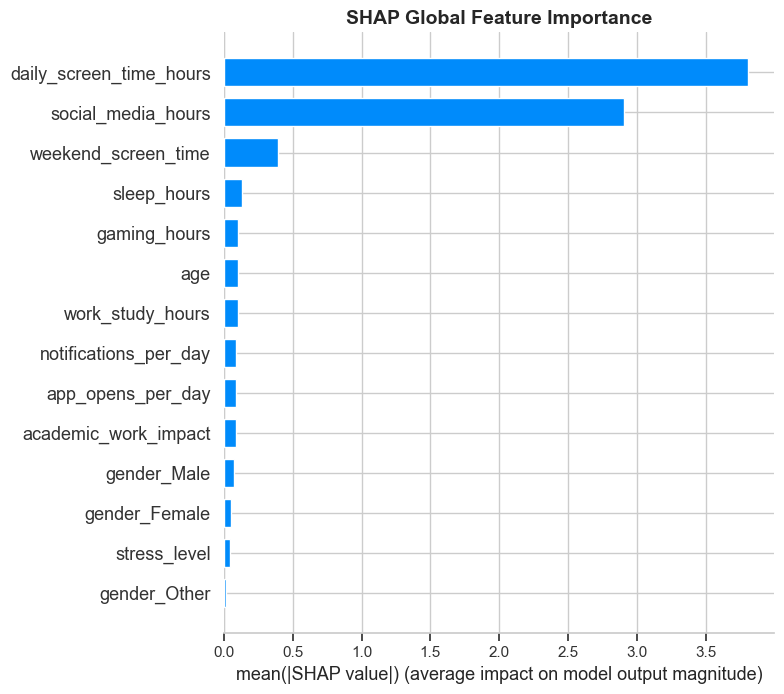

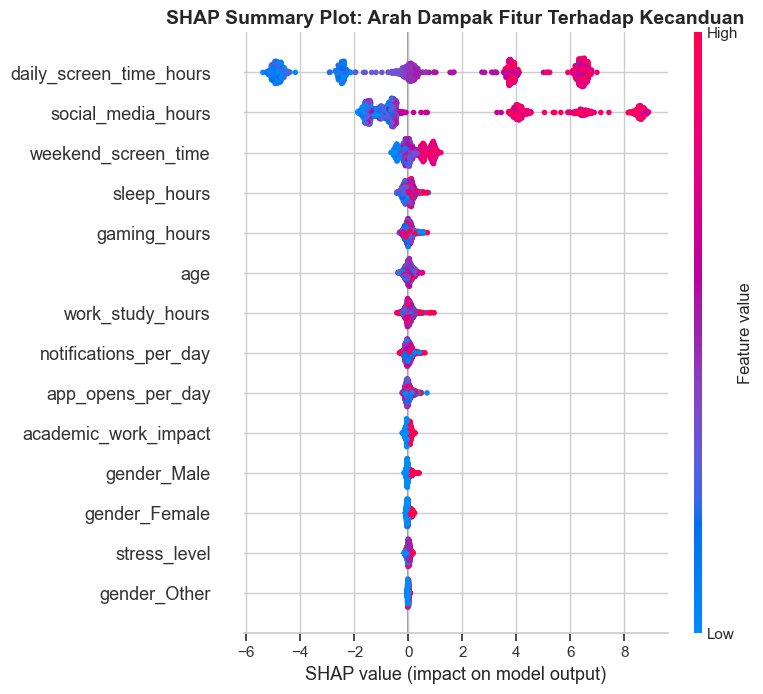


=== Penjelasan Prediksi untuk 1 Individu (Indeks 0) ===


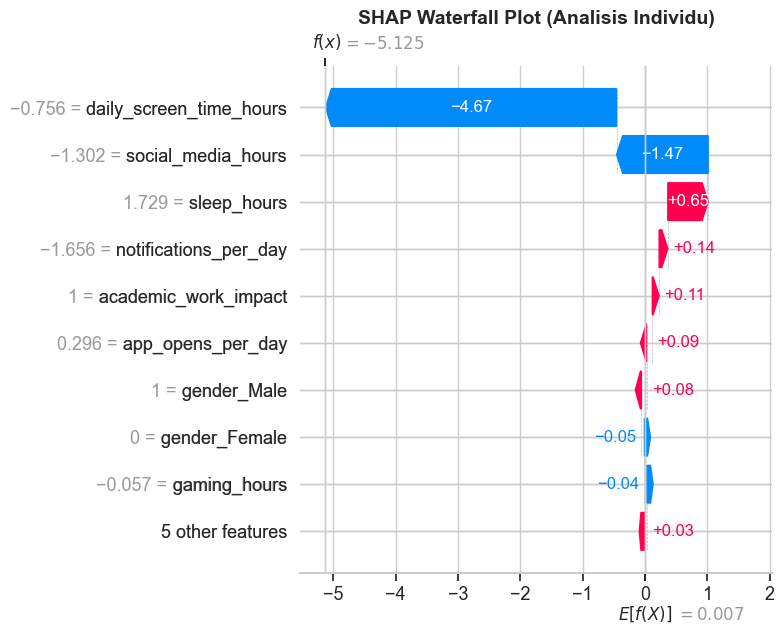

In [13]:
# ==========================================
# 7. EXPLAINABLE AI (XAI) MENGGUNAKAN SHAP
# ==========================================
import shap

# Inisialisasi JavaScript visualisasi untuk SHAP (jika pakai Jupyter Notebook/Lab)
shap.initjs()

print("Menghitung nilai SHAP... (Ini mungkin memakan waktu beberapa detik)")
# Menggunakan TreeExplainer yang dioptimalkan untuk XGBoost/Random Forest
explainer = shap.TreeExplainer(xgb_model)

# Menghitung SHAP values menggunakan data uji (X_test)
# Kita pakai X_test agar penjelasannya berdasarkan data yang belum pernah dilihat model
shap_values = explainer.shap_values(X_test)

# ---------------------------------------------------------
# VISUALISASI 1: SHAP Bar Plot (Global Feature Importance)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.title('SHAP Global Feature Importance', fontsize=14, fontweight='bold')
# Menampilkan rata-rata absolut dampak setiap fitur
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# VISUALISASI 2: SHAP Summary Plot / Beeswarm Plot (Paling Penting untuk Jurnal!)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.title('SHAP Summary Plot: Arah Dampak Fitur Terhadap Kecanduan', fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# VISUALISASI 3: SHAP Waterfall Plot (Local Explanation - Contoh 1 Orang)
# ---------------------------------------------------------
# Kita ambil sampel pasien/pengguna indeks ke-0 dari data uji
print("\n=== Penjelasan Prediksi untuk 1 Individu (Indeks 0) ===")
explainer_waterfall = shap.Explainer(xgb_model)
shap_values_waterfall = explainer_waterfall(X_test)

plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_values_waterfall[0], show=False)
plt.title('SHAP Waterfall Plot (Analisis Individu)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()